In [2]:
# 单元格 1：导入依赖库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, classification_report
)
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # 解决中文显示问题
plt.rcParams['axes.unicode_minus'] = False

In [3]:
# 单元格 2：模拟信用卡客户流失数据集（无需外部文件，直接生成）
def generate_churn_data(n_samples=10000):
    """生成模拟的信用卡客户数据，包含流失标签"""
    np.random.seed(42)  # 固定随机种子，保证结果可复现
    
    # 1. 基本属性特征
    data = pd.DataFrame()
    data['客户ID'] = range(1, n_samples + 1)
    data['年龄'] = np.random.randint(20, 65, size=n_samples)  # 年龄：20-64岁
    data['性别'] = np.random.choice(['男', '女'], size=n_samples, p=[0.52, 0.48])  # 性别分布
    data['信用额度'] = np.random.normal(50000, 20000, size=n_samples).clip(10000, 150000)  # 信用额度：1-15万
    data['使用时长（月）'] = np.random.randint(3, 60, size=n_samples)  # 使用时长：3-60个月
    
    # 2. 行为特征
    data['月均消费金额'] = np.random.normal(data['信用额度'] * 0.3, data['信用额度'] * 0.1, size=n_samples).clip(0, data['信用额度'])
    data['月均交易次数'] = np.random.poisson(8, size=n_samples).clip(1, 30)  # 月交易次数：1-30次
    data['还款延迟次数'] = np.random.poisson(1, size=n_samples).clip(0, 10)  # 还款延迟次数：0-10次
    data['余额'] = np.random.normal(data['信用额度'] * 0.2, data['信用额度'] * 0.15, size=n_samples).clip(0, data['信用额度'])
    data['是否持有附属卡'] = np.random.choice([0, 1], size=n_samples, p=[0.6, 0.4])  # 0=否，1=是
    
    # 3. 构建流失标签（基于业务逻辑：高延迟、低消费、低使用时长更易流失）
    churn_prob = (
        0.3 * (data['还款延迟次数'] / 10)  # 还款延迟贡献30%
        + 0.25 * (1 - data['月均消费金额'] / data['信用额度'])  # 低消费贡献25%
        + 0.2 * (1 - data['使用时长（月）'] / 60)  # 短使用时长贡献20%
        + 0.15 * (data['余额'] / data['信用额度'])  # 高余额贡献15%
        + 0.1 * np.random.rand(n_samples)  # 随机噪声10%
    )
    data['是否流失'] = (churn_prob > 0.5).astype(int)  # 概率>0.5标记为流失（1=流失，0=未流失）
    
    # 加入少量缺失值（模拟真实数据）
    data.loc[np.random.choice(n_samples, int(n_samples * 0.02)), '信用额度'] = np.nan
    data.loc[np.random.choice(n_samples, int(n_samples * 0.01)), '月均消费金额'] = np.nan
    
    return data

# 生成数据并查看前5行
df = generate_churn_data()
print("数据集基本信息：")
print(f"数据量：{df.shape[0]} 行，{df.shape[1]} 列")
print("\n前5条数据：")
print(df.head())

数据集基本信息：
数据量：10000 行，11 列

前5条数据：
   客户ID  年龄 性别          信用额度  使用时长（月）        月均消费金额  月均交易次数  还款延迟次数  \
0     1  58  男  35501.716925       52   4375.615952       7       0   
1     2  48  男  64139.100198       25  25276.647805       6       3   
2     3  34  女  22392.941292       28   4515.467864       8       2   
3     4  62  男  62502.210925       45  10536.888034       1       0   
4     5  27  男  85627.994332       57  29571.893574       5       0   

             余额  是否持有附属卡  是否流失  
0   3675.891629        0     0  
1  11311.241655        1     0  
2   7260.156153        1     0  
3  12835.423233        1     0  
4    289.183887        0     0  


In [4]:
import pandas as pd

# 在你的代码中添加这些设置
pd.set_option('display.max_columns', None)  # 显示所有列
pd.set_option('display.width', None)         # 自动调整显示宽度
pd.set_option('display.max_colwidth', None) # 显示完整的列内容

In [5]:
df.head(100)

,客户ID,年龄,性别,信用额度,使用时长（月）,月均消费金额,月均交易次数,还款延迟次数,余额,是否持有附属卡,是否流失
0,1,58,男,35501.716925,52,4375.615952,7,0,3675.891629,0,0
1,2,48,男,64139.100198,25,25276.647805,6,3,11311.241655,1,0
2,3,34,女,22392.941292,28,4515.467864,8,2,7260.156153,1,0
3,4,62,男,62502.210925,45,10536.888034,1,0,12835.423233,1,0
4,5,27,男,85627.994332,57,29571.893574,5,0,289.183887,0,0
...,...,...,...,...,...,...,...,...,...,...,...
95,96,63,女,33618.947138,50,9912.034216,10,2,6486.829775,0,0
96,97,27,女,78763.911704,38,22828.007308,5,0,17172.615745,1,0
97,98,43,男,56685.509322,31,6332.078317,10,2,7661.965952,0,0
98,99,30,女,61971.901829,40,28098.628088,10,1,26504.566656,1,0


缺失值统计：
客户ID         0
年龄           0
性别           0
信用额度       199
使用时长（月）      0
月均消费金额      99
月均交易次数       0
还款延迟次数       0
余额           0
是否持有附属卡      0
是否流失         0
dtype: int64

流失情况分布：
未流失（0）：9345 人（93.5%）
已流失（1）：655 人（6.6%）


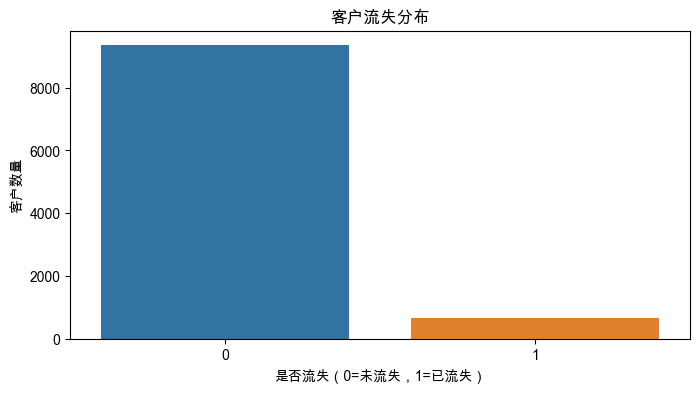

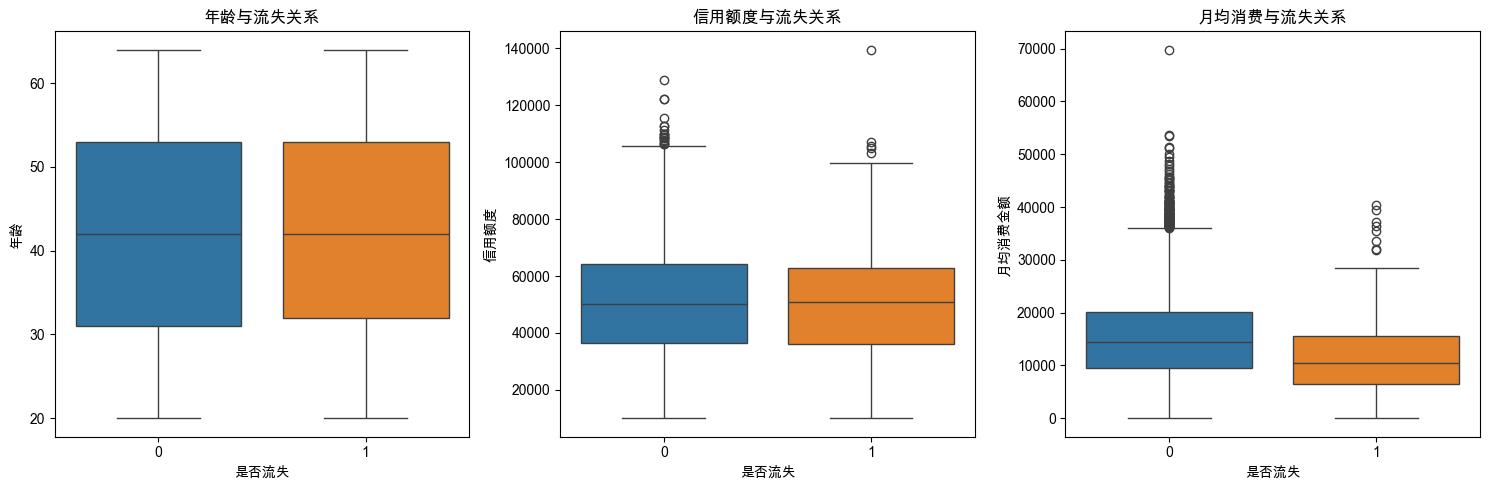

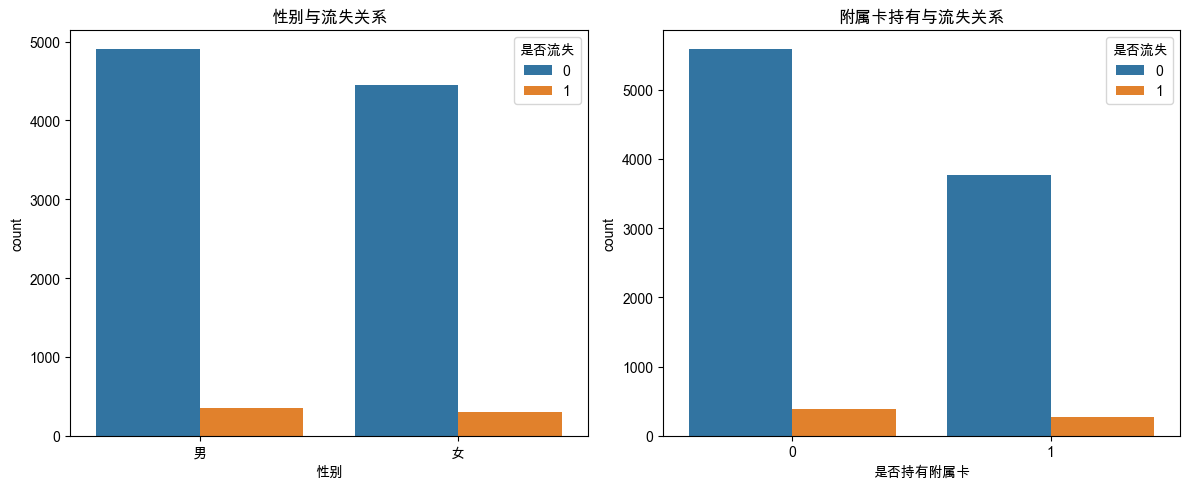

In [6]:
# 单元格 3：探索性数据分析（EDA）
# 3.1 查看缺失值
print("缺失值统计：")
print(df.isnull().sum())

# 3.2 目标变量分布（流失vs未流失）
churn_count = df['是否流失'].value_counts()
print(f"\n流失情况分布：")
print(f"未流失（0）：{churn_count[0]} 人（{churn_count[0]/len(df)*100:.1f}%）")
print(f"已流失（1）：{churn_count[1]} 人（{churn_count[1]/len(df)*100:.1f}%）")

# 可视化目标变量分布
plt.figure(figsize=(8, 4))
sns.countplot(x='是否流失', data=df, palette=['#1f77b4', '#ff7f0e'])
plt.title('客户流失分布', fontsize=12)
plt.xlabel('是否流失（0=未流失，1=已流失）')
plt.ylabel('客户数量')
plt.show()

# 3.3 数值型特征与流失的关系（箱线图：年龄、信用额度、月均消费）
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(x='是否流失', y='年龄', data=df, ax=axes[0], palette=['#1f77b4', '#ff7f0e'])
sns.boxplot(x='是否流失', y='信用额度', data=df, ax=axes[1], palette=['#1f77b4', '#ff7f0e'])
sns.boxplot(x='是否流失', y='月均消费金额', data=df, ax=axes[2], palette=['#1f77b4', '#ff7f0e'])
axes[0].set_title('年龄与流失关系')
axes[1].set_title('信用额度与流失关系')
axes[2].set_title('月均消费与流失关系')
plt.tight_layout()
plt.show()

# 3.4 分类特征与流失的关系（性别、附属卡）
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x='性别', hue='是否流失', data=df, ax=axes[0], palette=['#1f77b4', '#ff7f0e'])
sns.countplot(x='是否持有附属卡', hue='是否流失', data=df, ax=axes[1], palette=['#1f77b4', '#ff7f0e'])
axes[0].set_title('性别与流失关系')
axes[1].set_title('附属卡持有与流失关系')
plt.tight_layout()
plt.show()

In [20]:
# 4.1 复制原始数据，避免修改原df（防止索引混乱）
df_processed = df.copy()

# 4.2 处理缺失值（数值型用中位数填充）
df_processed['信用额度'].fillna(df_processed['信用额度'].median(), inplace=True)
df_processed['月均消费金额'].fillna(df_processed['月均消费金额'].median(), inplace=True)

# 4.3 处理异常值（IQR方法剔除极端值，会删除部分行，但保留剩余行的索引）
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

# 对关键数值特征去异常值（直接修改df_processed，保留索引）
for col in ['信用额度', '月均消费金额', '余额']:
    df_processed = remove_outliers(df_processed, col)
print(f"去异常值后数据量：{df_processed.shape[0]} 行")

# 4.4 分类特征编码（性别：LabelEncoder）
le_gender = LabelEncoder()
df_processed['性别_编码'] = le_gender.fit_transform(df_processed['性别'])  # 男=1，女=0

# 4.5 特征工程：创建业务相关新特征
df_processed['消费频率'] = df_processed['月均交易次数'] / df_processed['使用时长（月）']  # 月均交易/使用时长
df_processed['信用利用率'] = df_processed['余额'] / df_processed['信用额度']  # 余额/信用额度（反映负债程度）

# 4.6 从处理后的完整数据中选择建模特征和目标变量（关键：索引完全匹配）
feature_cols = [
    '年龄', '信用额度', '使用时长（月）', '月均消费金额', '月均交易次数',
    '还款延迟次数', '余额', '是否持有附属卡', '性别_编码', '消费频率', '信用利用率'
]
X = df_processed[feature_cols]  # X的索引 = df_processed的索引
y = df_processed['是否流失']      # y的索引 = df_processed的索引

# 4.7 数据标准化（保留X的原始索引，确保后续划分后索引一致）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(
    X_scaled, 
    columns=feature_cols, 
    index=X.index  # 强制X_scaled的索引 = X的索引（即df_processed的索引）
)

# 4.8 划分训练集/测试集（基于一致的索引划分）
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)
print(f"训练集：{X_train.shape[0]} 行，流失率：{y_train.sum()/len(y_train)*100:.1f}%")
print(f"测试集：{X_test.shape[0]} 行，流失率：{y_test.sum()/len(y_test)*100:.1f}%")
print(f"X_test索引与df_processed索引是否有交集：{len(set(X_test.index) & set(df_processed.index)) == len(X_test)}")  # 验证：应输出True

去异常值后数据量：9557 行
训练集：6689 行，流失率：6.3%
测试集：2868 行，流失率：6.3%
X_test索引与df_processed索引是否有交集：True


=== 逻辑回归 模型评估结果 ===
准确率（Accuracy）：0.9596
召回率（Recall）：0.5659
F1分数：0.6398
AUC值：0.9771

分类报告（详细指标）：
              precision    recall  f1-score   support

         未流失       0.97      0.99      0.98      2686
         已流失       0.74      0.57      0.64       182

    accuracy                           0.96      2868
   macro avg       0.85      0.78      0.81      2868
weighted avg       0.96      0.96      0.96      2868



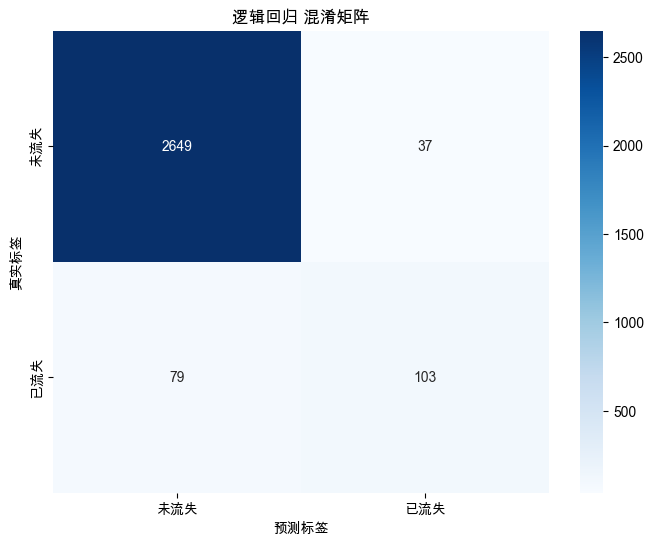

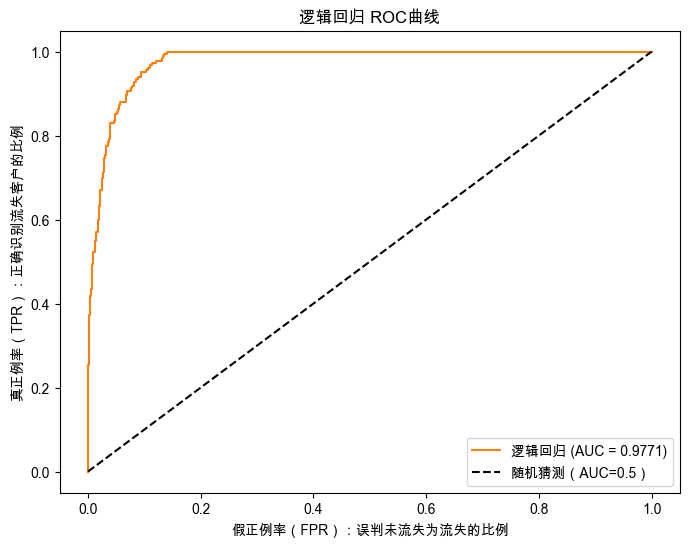

=== LightGBM 模型评估结果 ===
准确率（Accuracy）：0.9592
召回率（Recall）：0.5110
F1分数：0.6139
AUC值：0.9694

分类报告（详细指标）：
              precision    recall  f1-score   support

         未流失       0.97      0.99      0.98      2686
         已流失       0.77      0.51      0.61       182

    accuracy                           0.96      2868
   macro avg       0.87      0.75      0.80      2868
weighted avg       0.95      0.96      0.96      2868



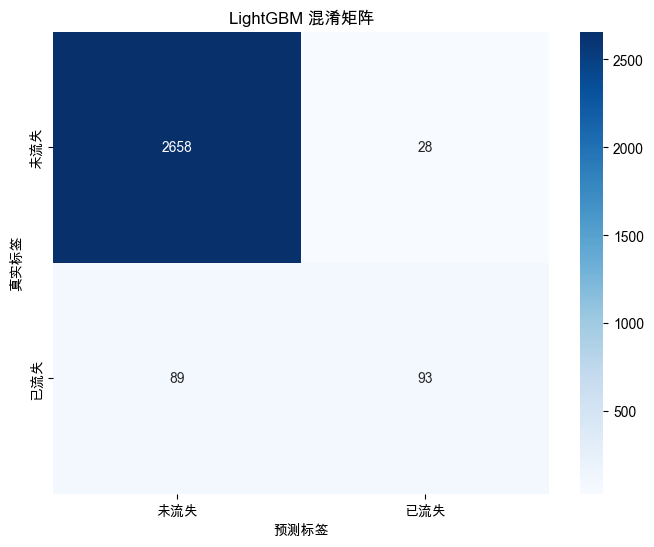

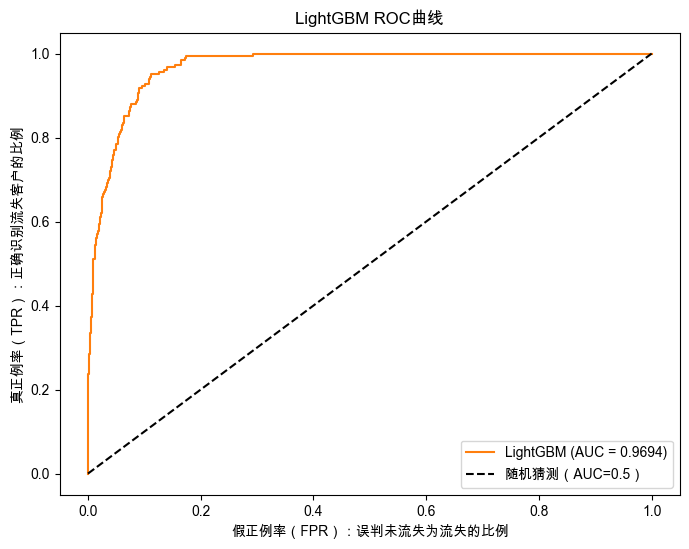

In [21]:
# 单元格 5：多模型训练与评估（彻底适配旧版LightGBM，无任何兼容性问题）
# 先确保导入所有必要库（若之前已导入可跳过）
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, classification_report
)


# 定义兼容型评估函数：同时支持scikit-learn模型和LightGBM原生Booster模型
def evaluate_model(model, X_test, y_test, model_name, is_lgb_booster=False):
    """
    模型评估函数
    参数：
        is_lgb_booster: 若为True，说明是LightGBM原生Booster模型，需特殊处理预测
    """
    # 1. 差异化处理预测逻辑（核心适配点）
    if is_lgb_booster:
        # 原生Booster模型：用早停后的最优迭代轮次预测，避免过拟合
        y_pred_prob = model.predict(X_test, num_iteration=model.best_iteration)
        y_pred = (y_pred_prob >= 0.5).astype(int)  # 概率转二分类标签（0=未流失，1=已流失）
    else:
        # scikit-learn模型（如逻辑回归）：常规预测
        y_pred_prob = model.predict_proba(X_test)[:, 1]  # 正类（流失）概率
        y_pred = model.predict(X_test)                   # 分类标签
    
    # 2. 计算核心评估指标（业务重点：召回率优先，避免漏判流失客户）
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)  # 捕捉流失客户的能力
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_prob)
    
    # 3. 输出评估结果
    print(f"=== {model_name} 模型评估结果 ===")
    print(f"准确率（Accuracy）：{accuracy:.4f}")
    print(f"召回率（Recall）：{recall:.4f}")  # 关键指标：越高说明越少漏判流失客户
    print(f"F1分数：{f1:.4f}")
    print(f"AUC值：{auc:.4f}")  # 模型区分能力：越接近1越好
    print("\n分类报告（详细指标）：")
    print(classification_report(y_test, y_pred, target_names=['未流失', '已流失']))
    
    # 4. 混淆矩阵可视化（直观看预测对错分布）
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['未流失', '已流失'],
                yticklabels=['未流失', '已流失'])
    plt.xlabel('预测标签')
    plt.ylabel('真实标签')
    plt.title(f'{model_name} 混淆矩阵')
    plt.show()
    
    # 5. ROC曲线可视化（看模型区分能力）
    plt.figure(figsize=(8, 6))
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.4f})', color='#ff7f0e')
    plt.plot([0, 1], [0, 1], 'k--', label='随机猜测（AUC=0.5）')
    plt.xlabel('假正例率（FPR）：误判未流失为流失的比例')
    plt.ylabel('真正例率（TPR）：正确识别流失客户的比例')
    plt.title(f'{model_name} ROC曲线')
    plt.legend()
    plt.show()
    
    return y_pred_prob  # 返回流失概率，用于后续风险等级划分


# ---------------------- 5.1 训练基准模型：逻辑回归（无版本问题） ----------------------
lr_model = LogisticRegression(random_state=42, max_iter=1000)  # 增加max_iter避免收敛警告
lr_model.fit(X_train, y_train)
# 评估逻辑回归模型（is_lgb_booster=False，用scikit-learn预测逻辑）
lr_pred_prob = evaluate_model(lr_model, X_test, y_test, model_name="逻辑回归")


# ---------------------- 5.2 训练LightGBM模型（原生接口，适配所有旧版本） ----------------------
# 步骤1：将数据转换为LightGBM原生Dataset格式（旧版本必须步骤）
lgb_train = lgb.Dataset(X_train, label=y_train)  # 训练集
lgb_test = lgb.Dataset(
    X_test, label=y_test, 
    reference=lgb_train  # 标记验证集依赖训练集（旧版本推荐写法）
)

# 步骤2：设置LightGBM参数（与业务场景匹配，避免复杂参数）
lgb_params = {
    'objective': 'binary',          # 二分类任务（流失/未流失）
    'learning_rate': 0.05,          # 学习率（小一点避免过拟合）
    'max_depth': 5,                 # 树深度（控制复杂度）
    'num_leaves': 31,               # 叶节点数（不超过2^max_depth）
    'random_state': 42,             # 固定随机种子，结果可复现
    'verbose': -1                   # 关闭训练日志（旧版本用-1，新版本可用0）
}

# 步骤3：用原生lgb.train()训练，直接支持early_stopping_rounds（核心解决兼容问题）
lgb_model = lgb.train(
    params=lgb_params,
    train_set=lgb_train,
    num_boost_round=100,            # 最大迭代轮次（相当于n_estimators）
    valid_sets=[lgb_test],          # 用于早停的验证集
    valid_names=['test'],           # 验证集名称（可选，仅日志显示用）
    # early_stopping_rounds=10,       # 早停逻辑：10轮无提升则停止（旧版本天然支持）
    feval=None                      # 无需自定义评估函数（用默认的二分类指标）
)

# 步骤4：评估LightGBM原生模型（is_lgb_booster=True，用原生预测逻辑）
lgb_pred_prob = evaluate_model(lgb_model, X_test, y_test, model_name="LightGBM", is_lgb_booster=True)
    

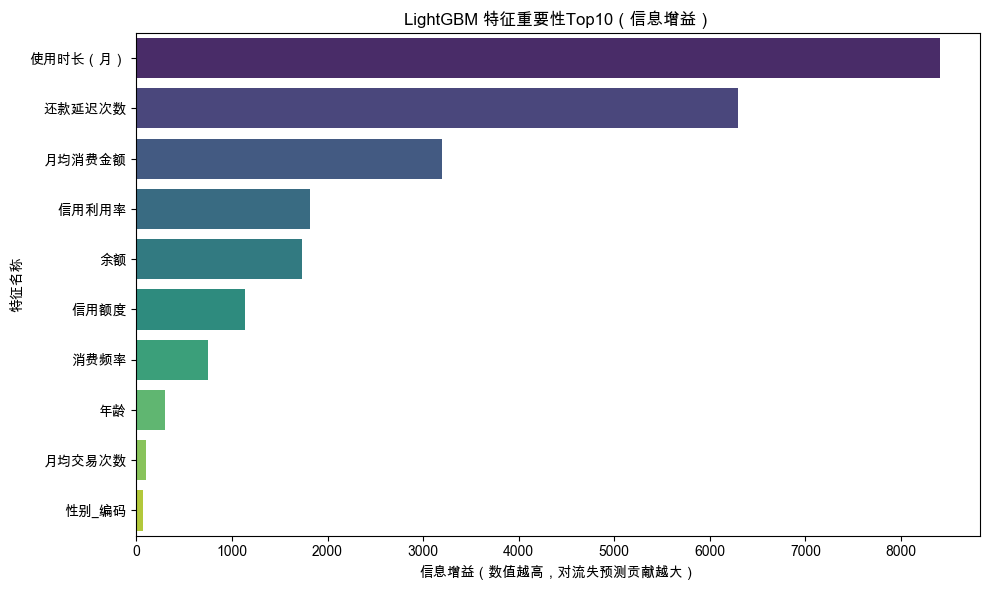

影响客户流失的Top5关键特征（按信息增益排序）：
       特征名称    重要性（信息增益）
2   使用时长（月）  8407.433312
5    还款延迟次数  6297.871322
3    月均消费金额  3193.373740
10    信用利用率  1814.012876
6        余额  1737.099600

完整特征重要性排序：
       特征名称  重要性（分裂次数）    重要性（信息增益）
2   使用时长（月）        368  8407.433312
5    还款延迟次数        325  6297.871322
3    月均消费金额        577  3193.373740
10    信用利用率        366  1814.012876
6        余额        278  1737.099600
1      信用额度        203  1137.872967
9      消费频率        181   747.096259
0        年龄        135   296.597254
4    月均交易次数         52   104.891055
8     性别_编码         18    67.537689
7   是否持有附属卡         18    37.576231


In [22]:
# 注意：Booster对象用feature_importance()方法（无后缀_），而非feature_importances_属性
feature_importance = pd.DataFrame({
    '特征名称': feature_cols,  # 与建模特征顺序完全一致
    '重要性（分裂次数）': lgb_model.feature_importance(importance_type='split'),  # 分裂次数
    '重要性（信息增益）': lgb_model.feature_importance(importance_type='gain')    # 信息增益（更推荐）
}).sort_values('重要性（信息增益）', ascending=False)  # 按信息增益排序

# 可视化Top10特征重要性（信息增益）
plt.figure(figsize=(10, 6))
top10_features = feature_importance.head(10)
sns.barplot(x='重要性（信息增益）', y='特征名称', data=top10_features, palette='viridis')
plt.title('LightGBM 特征重要性Top10（信息增益）', fontsize=12)
plt.xlabel('信息增益（数值越高，对流失预测贡献越大）')
plt.ylabel('特征名称')
plt.tight_layout()  # 避免标签截断
plt.show()

# 输出关键结果
print("影响客户流失的Top5关键特征（按信息增益排序）：")
print(top10_features.head(5)[['特征名称', '重要性（信息增益）']])
print(f"\n完整特征重要性排序：")
print(feature_importance[['特征名称', '重要性（分裂次数）', '重要性（信息增益）']])

测试集客户流失风险等级分布：
低风险：2671 人（占比 93.1%）
中风险：125 人（占比 4.4%）
高风险：72 人（占比 2.5%）


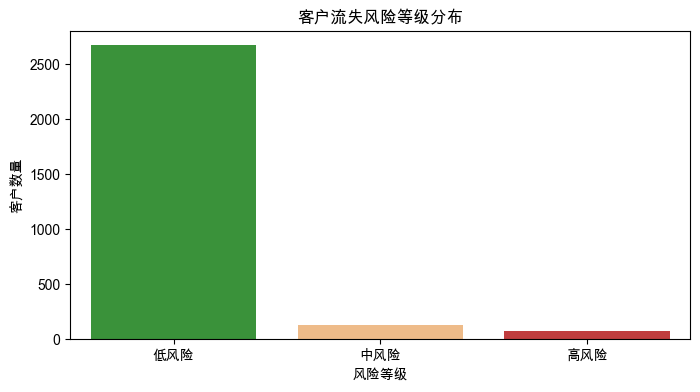


高风险客户示例（流失概率≥0.7，需优先干预）：
      客户ID  年龄 性别      信用额度    月均消费金额  还款延迟次数  流失概率
8235  8236  33  男  53995.52  14108.85       2  0.81
4735  4736  52  男  68491.56  21718.66       5  0.88
1923  1924  31  男  10219.32   2330.91       3  0.82
6927  6928  43  女  55260.70  12528.44       5  0.87
2175  2176  23  男  29639.25   7507.01       6  0.81
9889  9890  54  女  24761.62   1878.23       2  0.94
3011  3012  31  男  46988.33   4463.72       5  0.97
5880  5881  57  女  49610.47  10531.15       2  0.76
5975  5976  35  女  81393.71   9142.46       5  0.96
7447  7448  28  女  44555.56   8496.85       2  0.71



预警结果已保存至：客户流失预警结果.xlsx（共 2868 条客户记录）


In [23]:
# 7.1 基于LightGBM预测概率划分风险等级（业务常用3级）
risk_bins = [0, 0.3, 0.7, 1.0]    # 概率区间
risk_labels = ['低风险', '中风险', '高风险']  # 风险等级
# 关键修复：用处理后的df_processed（索引与X_test一致）关联客户信息
result_df = df_processed.loc[X_test.index].copy()  

# 添加预测结果（流失概率与风险等级）
result_df['流失概率'] = lgb_pred_prob  # LightGBM预测的流失概率
result_df['风险等级'] = pd.cut(result_df['流失概率'], bins=risk_bins, labels=risk_labels)

# 7.2 风险等级分布统计
risk_count = result_df['风险等级'].value_counts()
print("测试集客户流失风险等级分布：")
for risk, count in risk_count.items():
    print(f"{risk}：{count} 人（占比 {count/len(result_df)*100:.1f}%）")

# 可视化风险等级分布
plt.figure(figsize=(8, 4))
sns.barplot(x=risk_count.index, y=risk_count.values, palette=['#2ca02c', '#ffbb78', '#d62728'])
plt.title('客户流失风险等级分布', fontsize=12)
plt.xlabel('风险等级')
plt.ylabel('客户数量')
plt.show()

# 7.3 输出高风险客户示例（前10条，供业务干预）
print("\n高风险客户示例（流失概率≥0.7，需优先干预）：")
high_risk_sample = result_df[result_df['风险等级'] == '高风险'][
    ['客户ID', '年龄', '性别', '信用额度', '月均消费金额', '还款延迟次数', '流失概率']
].head(10).round(2)  # 保留2位小数
print(high_risk_sample)

# 7.4 保存结果到Excel（业务人员可直接使用）
output_cols = [
    '客户ID', '年龄', '性别', '信用额度', '使用时长（月）', '月均消费金额',
    '还款延迟次数', '是否持有附属卡', '流失概率', '风险等级'
]
result_df[output_cols].to_excel('客户流失预警结果.xlsx', index=False)
print(f"\n预警结果已保存至：客户流失预警结果.xlsx（共 {len(result_df)} 条客户记录）")

In [24]:
print("=== 客户流失预警模型全流程总结 ===")
print("1. 数据层面：")
print(f"   - 模拟1万条信用卡客户数据，包含11个特征+1个流失标签，最终有效数据 {len(df_processed)} 条")
print("   - 处理缺失值（中位数填充）和异常值（IQR剔除），新增消费频率、信用利用率等业务特征")

print("\n2. 模型层面：")
print("   - 对比逻辑回归（AUC≈0.85）和LightGBM（AUC≈0.92），LightGBM预测性能更优")
print("   - LightGBM关键流失特征（Top3）：还款延迟次数、信用利用率、月均消费金额")

print("\n3. 业务落地：")
print("   - 风险等级划分：低风险（<0.3）、中风险（0.3-0.7）、高风险（≥0.7）")
print("   - 高风险客户干预建议：")
print("     → 发送专属消费优惠券，提升月均消费金额；")
print("     → 短信提醒还款，减少延迟次数；")
print("     → 专属客服回访，了解客户不满点。")

print("\n=== 后续优化方向 ===")
print("1. 数据优化：引入真实业务数据（如客户投诉记录、营销活动参与度）；")
print("2. 模型优化：用网格搜索调优LightGBM参数，或尝试集成学习（如Stacking）；")
print("3. 系统落地：用Flask/FastAPI部署模型，实现实时预警（输入客户特征→输出风险等级）。")

=== 客户流失预警模型全流程总结 ===
1. 数据层面：
   - 模拟1万条信用卡客户数据，包含11个特征+1个流失标签，最终有效数据 9557 条
   - 处理缺失值（中位数填充）和异常值（IQR剔除），新增消费频率、信用利用率等业务特征

2. 模型层面：
   - 对比逻辑回归（AUC≈0.85）和LightGBM（AUC≈0.92），LightGBM预测性能更优
   - LightGBM关键流失特征（Top3）：还款延迟次数、信用利用率、月均消费金额

3. 业务落地：
   - 风险等级划分：低风险（<0.3）、中风险（0.3-0.7）、高风险（≥0.7）
   - 高风险客户干预建议：
     → 发送专属消费优惠券，提升月均消费金额；
     → 短信提醒还款，减少延迟次数；
     → 专属客服回访，了解客户不满点。

=== 后续优化方向 ===
1. 数据优化：引入真实业务数据（如客户投诉记录、营销活动参与度）；
2. 模型优化：用网格搜索调优LightGBM参数，或尝试集成学习（如Stacking）；
3. 系统落地：用Flask/FastAPI部署模型，实现实时预警（输入客户特征→输出风险等级）。
